In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qnli"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question', 'sentence', 'label', 'idx'],
    num_rows: 104743
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question': 'When did the third Digimon series begin?',
 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question'], raw_train_dataset[5]['sentence']

("When is the term 'German dialects' used in regard to the German language?",
 'When talking about the German language, the term German dialects is only used for the traditional regional varieties.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question': Value('string'),
 'sentence': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question"], example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question", "sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 84]),
 'token_type_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7970, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}

### Load Trained Weights for Model with 8 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [32]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [33]:
len(model_8.bert.encoder.layer)

8

In [34]:
model_8.to(device)
device

device(type='cuda', index=1)

In [35]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.8991396668497162}

### Load Trained Weights for Model with 7 Layers

In [37]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [39]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [40]:
len(model_7.bert.encoder.layer)

7

In [41]:
model_7.to(device)
device

device(type='cuda', index=1)

In [42]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.9018854109463664}

### Load Trained Weights for Model with 6 Layers

In [44]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [46]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [47]:
len(model_6.bert.encoder.layer)

6

In [48]:
model_6.to(device)
device

device(type='cuda', index=1)

In [49]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [50]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.8832143510891451}

In [51]:
print(model.bert.encoder.layer[0].state_dict().keys())

odict_keys(['attention.self.query.weight', 'attention.self.query.bias', 'attention.self.key.weight', 'attention.self.key.bias', 'attention.self.value.weight', 'attention.self.value.bias', 'attention.output.dense.weight', 'attention.output.dense.bias', 'attention.output.LayerNorm.weight', 'attention.output.LayerNorm.bias', 'intermediate.dense.weight', 'intermediate.dense.bias', 'output.dense.weight', 'output.dense.bias', 'output.LayerNorm.weight', 'output.LayerNorm.bias'])


# 5. Pruning Sweep — Depth Model vs Width Model

We compare how **two structurally different fine-tuned BERT variants** respond to
unstructured L1 weight pruning at five sparsity levels: **10%, 20%, 30%, 40%, 50%**.

| Model | Structure |
|---|---|
| `model` | Standard BERT-base (12 layers, depth) |
| `graft_model` | Width-merged BERT (6 layers, 2× internal width) |

### GPU-efficient strategy
- Both models stay on GPU throughout — no `.to(device)` inside the loop
- Original dense weights are cached **once** as CPU tensors
- Between pruning levels, weights are restored via a CPU→GPU `load_state_dict` copy
- Stale masks are stripped with `remove_all_masks()` before each new level


In [52]:
from prune_helper import remove_all_masks, apply_pruning, global_sparsity, make_permanent, compare_pruning_robustness, print_pruning_results

In [53]:
# Cache both models' dense weights on CPU — cheap to store, cheap to restore
depth_state_cpu = {k: v.cpu().clone() for k, v in model.state_dict().items()}
width_state_8_cpu = {k: v.cpu().clone() for k, v in model_8.state_dict().items()}
width_state_7_cpu = {k: v.cpu().clone() for k, v in model_7.state_dict().items()}
width_state_6_cpu = {k: v.cpu().clone() for k, v in model_6.state_dict().items()}

print(f'Depth model: {len(depth_state_cpu)} tensors cached on CPU')
print(f'Width model (8 layers): {len(width_state_8_cpu)} tensors cached on CPU')
print(f'Width model (7 layers): {len(width_state_7_cpu)} tensors cached on CPU')
print(f'Width model (6 layers): {len(width_state_6_cpu)} tensors cached on CPU')
print(f'GPU device : {device}')


Depth model: 201 tensors cached on CPU
Width model (8 layers): 137 tensors cached on CPU
Width model (7 layers): 121 tensors cached on CPU
Width model (6 layers): 105 tensors cached on CPU
GPU device : cuda:1


In [54]:
model.eval()
model_8.eval()
model_7.eval()
model_6.eval()

baseline_depth, _ = eval_loop(model, val_dataloader, task_name, device)
baseline_width_8, _ = eval_loop(model_8, val_dataloader, task_name, device)
baseline_width_7, _ = eval_loop(model_7, val_dataloader, task_name, device)
baseline_width_6, _ = eval_loop(model_6, val_dataloader, task_name, device)

print(f'Baseline — Depth model (12-layer)')
for metric_name, value in baseline_depth.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (8-layer)')
for metric_name, value in baseline_width_8.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (7-layer)')
for metric_name, value in baseline_width_7.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (6-layer)')
for metric_name, value in baseline_width_6.items():
    print(f"- {metric_name}: {value:.4f}")


Baseline — Depth model (12-layer)
- accuracy: 0.9134
Baseline — Width model (8-layer)
- accuracy: 0.8991
Baseline — Width model (7-layer)
- accuracy: 0.9019
Baseline — Width model (6-layer)
- accuracy: 0.8832


In [55]:
# Pass models with baselines
models = {
    '12-layer': (model, baseline_depth),
    '8-layer': (model_8, baseline_width_8),
    '7-layer': (model_7, baseline_width_7),
    '6-layer': (model_6, baseline_width_6),
}

In [56]:
results = compare_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,  # or eval_dataloader
    task_name=task_name,
    device=device,
    pruning_levels=[0.10, 0.20, 0.30, 0.40, 0.50],
    save_checkpoints=False
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
  ★ accuracy: 0.9134

8-layer:
  ★ accuracy: 0.8991

7-layer:
  ★ accuracy: 0.9019

6-layer:
  ★ accuracy: 0.8832

PRUNING SWEEP

════════════════════════════════════════════════════════════
  Pruning Level: 10%
════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.9151  (Δ -0.0016)
    Sparsity: 10.00%

  [8-layer]
    Accuracy: 0.8993  (Δ -0.0002)
    Sparsity: 10.00%

  [7-layer]
    Accuracy: 0.9021  (Δ -0.0002)
    Sparsity: 10.00%

  [6-layer]
    Accuracy: 0.8796  (Δ +0.0037)
    Sparsity: 10.00%

════════════════════════════════════════════════════════════
  Pruning Level: 20%
════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.9136  (Δ -0.0002)
    Sparsity: 20.00%

  [8-layer]
    Accuracy: 0.8995  (Δ -0.0004)
    Sparsity: 20.00%

  [7-layer]
    Accuracy: 0.9008 

In [57]:
# Print results
print_pruning_results(models, results)


PRUNING RESULTS SUMMARY

12-layer:
 Pruning %    Sparsity %      Accuracy  
--------------------------------------------------------------------------------
  0 (base)          0.00        0.9134  
        10         10.00        0.9151  
        20         20.00        0.9136  
        30         30.00        0.9121  
        40         40.00        0.8982  
        50         50.00        0.8234  

8-layer:
 Pruning %    Sparsity %      Accuracy  
--------------------------------------------------------------------------------
  0 (base)          0.00        0.8991  
        10         10.00        0.8993  
        20         20.00        0.8995  
        30         30.00        0.8942  
        40         40.00        0.8880  
        50         50.00        0.8567  

7-layer:
 Pruning %    Sparsity %      Accuracy  
--------------------------------------------------------------------------------
  0 (base)          0.00        0.9019  
        10         10.00        0.9021  
    

In [58]:
def plot_pruning_comparison(
    results_dict,
    models_dict=None,
    task_name=None,
    save_path=None,
    figsize=(14, 10),
    show_plots=True,
    plot_types=['metric_vs_pruning', 'metric_drop', 'marginal', 'retention']
):
    """
    Plot pruning comparison results for any GLUE task.
    Automatically handles different metrics (F1, accuracy, Pearson, Matthews, etc.)
    
    Args:
        results_dict: Results from compare_pruning_robustness()
        models_dict: Optional - original models dict for baseline info
        task_name: Optional - GLUE task name (auto-detects primary metric)
        save_path: Optional - path to save figure (default: None, don't save)
        figsize: Figure size (default: (14, 10))
        show_plots: Whether to display plots (default: True)
        plot_types: List of plots to include (default: all 4)
                   Options: 'metric_vs_pruning', 'metric_drop', 'marginal', 'retention'
    
    Returns:
        matplotlib figure object
    
    Examples:
        # MRPC (F1)
        plot_pruning_comparison(results, models, 'mrpc', 'mrpc_pruning.png')
        
        # SST-2 (Accuracy)
        plot_pruning_comparison(results, models, 'sst2', 'sst2_pruning.png')
        
        # CoLA (Matthews correlation)
        plot_pruning_comparison(results, models, 'cola', 'cola_pruning.png')
        
        # STS-B (Pearson correlation)
        plot_pruning_comparison(results, models, 'stsb', 'stsb_pruning.png')
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Detect primary metric
    primary_metric = None
    metric_display_name = None
    
    if task_name:
        from train_eval_func import get_primary_metric
        primary_metric = get_primary_metric(task_name)
        
        # Set display names
        metric_names = {
            'f1': 'F1',
            'accuracy': 'Accuracy',
            'matthews_correlation': 'Matthews Corr.',
            'pearson': 'Pearson Corr.',
            'spearmanr': 'Spearman Corr.',
        }
        metric_display_name = metric_names.get(primary_metric, primary_metric.capitalize())
    else:
        # Auto-detect from results
        first_label = list(results_dict.keys())[0]
        first_result = results_dict[first_label][0]
        
        # Find the metric (exclude special keys)
        for key in first_result.keys():
            if key not in ['pruning_pct', 'pruning_amount', 'global_sparsity'] and not key.endswith('_drop'):
                primary_metric = key
                metric_display_name = key.capitalize()
                break
    
    if not primary_metric:
        raise ValueError("Could not detect primary metric. Please provide task_name.")
    
    # Extract data
    labels = list(results_dict.keys())
    
    # Colors (support more models)
    default_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']
    color_map = {
        '12-layer': '#2196F3',
        '8-layer': '#4CAF50',
        '7-layer': '#FF9800',
        '6-layer': '#F44336',
    }
    colors = [color_map.get(label, default_colors[i % len(default_colors)]) 
              for i, label in enumerate(labels)]
    
    # Get baselines
    baselines = {}
    for label in labels:
        if models_dict and label in models_dict:
            if isinstance(models_dict[label], tuple):
                baselines[label] = models_dict[label][1][primary_metric]
            else:
                # Try to get from first result
                first_res = results_dict[label][0]
                if primary_metric in first_res:
                    baselines[label] = first_res[primary_metric]
                else:
                    raise ValueError(f"Cannot find {primary_metric} for {label}")
        else:
            # Infer from first result
            first_res = results_dict[label][0]
            if primary_metric in first_res:
                baselines[label] = first_res[primary_metric]
            else:
                raise ValueError(f"Cannot find {primary_metric} in results for {label}")
    
    # Prepare data
    pruning_levels = [0] + [r['pruning_pct'] for r in results_dict[labels[0]]]
    
    data = {}
    for label in labels:
        baseline = baselines[label]
        
        # Get metric scores
        scores = [baseline] + [r.get(primary_metric, baseline) for r in results_dict[label]]
        
        # Get drops (handle both formats)
        drop_key = f'{primary_metric}_drop'
        if drop_key in results_dict[label][0]:
            drops = [0] + [r[drop_key] for r in results_dict[label]]
        else:
            # Calculate manually
            drops = [baseline - score for score in scores]
        
        data[label] = {
            'scores': scores,
            'drops': drops,
            'baseline': baseline
        }
    
    # Determine subplot layout
    n_plots = len(plot_types)
    if n_plots == 4:
        nrows, ncols = 2, 2
    elif n_plots == 3:
        nrows, ncols = 2, 2
    elif n_plots == 2:
        nrows, ncols = 1, 2
    else:
        nrows, ncols = 1, 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    plot_idx = 0
    
    # Plot 1: Metric vs Pruning Level
    if 'metric_vs_pruning' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        for i, label in enumerate(labels):
            marker = ['o', 's', '^', 'd', 'v', 'p'][i % 6]
            ax.plot(pruning_levels, data[label]['scores'], 
                   f'{marker}-', color=colors[i], linewidth=2, markersize=8, label=label)
        
        ax.axvline(x=40, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
        ax.set_xlabel('Pruning Level (%)', fontsize=11)
        ax.set_ylabel(metric_display_name, fontsize=11)
        
        title = f'{metric_display_name} vs Pruning Level'
        if task_name:
            title += f' ({task_name.upper()})'
        ax.set_title(title, fontsize=12, fontweight='bold')
        
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(pruning_levels)
    
    # Plot 2: Drop vs Pruning Level
    if 'metric_drop' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        for i, label in enumerate(labels):
            marker = ['o', 's', '^', 'd', 'v', 'p'][i % 6]
            ax.plot(pruning_levels, data[label]['drops'],
                   f'{marker}-', color=colors[i], linewidth=2, markersize=8, label=label)
        
        ax.axvline(x=40, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.2, linewidth=1)
        ax.set_xlabel('Pruning Level (%)', fontsize=11)
        ax.set_ylabel(f'{metric_display_name} Drop', fontsize=11)
        ax.set_title(f'{metric_display_name} Degradation', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(pruning_levels)
    
    # Plot 3: Marginal Drop
    if 'marginal' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        bar_width = 0.8 / len(labels)
        x_pos = np.arange(len(pruning_levels) - 1)
        
        for i, label in enumerate(labels):
            marginal = [data[label]['drops'][j+1] - data[label]['drops'][j] 
                       for j in range(len(data[label]['drops'])-1)]
            offset = (i - len(labels)/2 + 0.5) * bar_width
            ax.bar(x_pos + offset, marginal, bar_width, 
                  label=label, color=colors[i])
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'{p}%' for p in pruning_levels[1:]])
        ax.set_xlabel('Pruning Step', fontsize=11)
        ax.set_ylabel(f'Marginal {metric_display_name} Drop', fontsize=11)
        ax.set_title('Marginal Degradation per Step', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.2, linewidth=1)
    
    # Plot 4: Retention Rate
    if 'retention' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        for i, label in enumerate(labels):
            marker = ['o', 's', '^', 'd', 'v', 'p'][i % 6]
            baseline = data[label]['baseline']
            retention = [score/baseline * 100 for score in data[label]['scores']]
            ax.plot(pruning_levels, retention,
                   f'{marker}-', color=colors[i], linewidth=2, markersize=8, label=label)
        
        ax.axhline(y=95, color='green', linestyle='--', alpha=0.3, linewidth=1.5, label='95% retention')
        ax.axvline(x=40, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
        ax.set_xlabel('Pruning Level (%)', fontsize=11)
        ax.set_ylabel(f'{metric_display_name} Retention (%)', fontsize=11)
        ax.set_title(f'{metric_display_name} Retention Rate', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='lower left')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(pruning_levels)
        ax.set_ylim([80, 102])
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'✓ Plot saved to {save_path}')
    
    # Show if requested
    if show_plots:
        plt.show()
    
    return fig

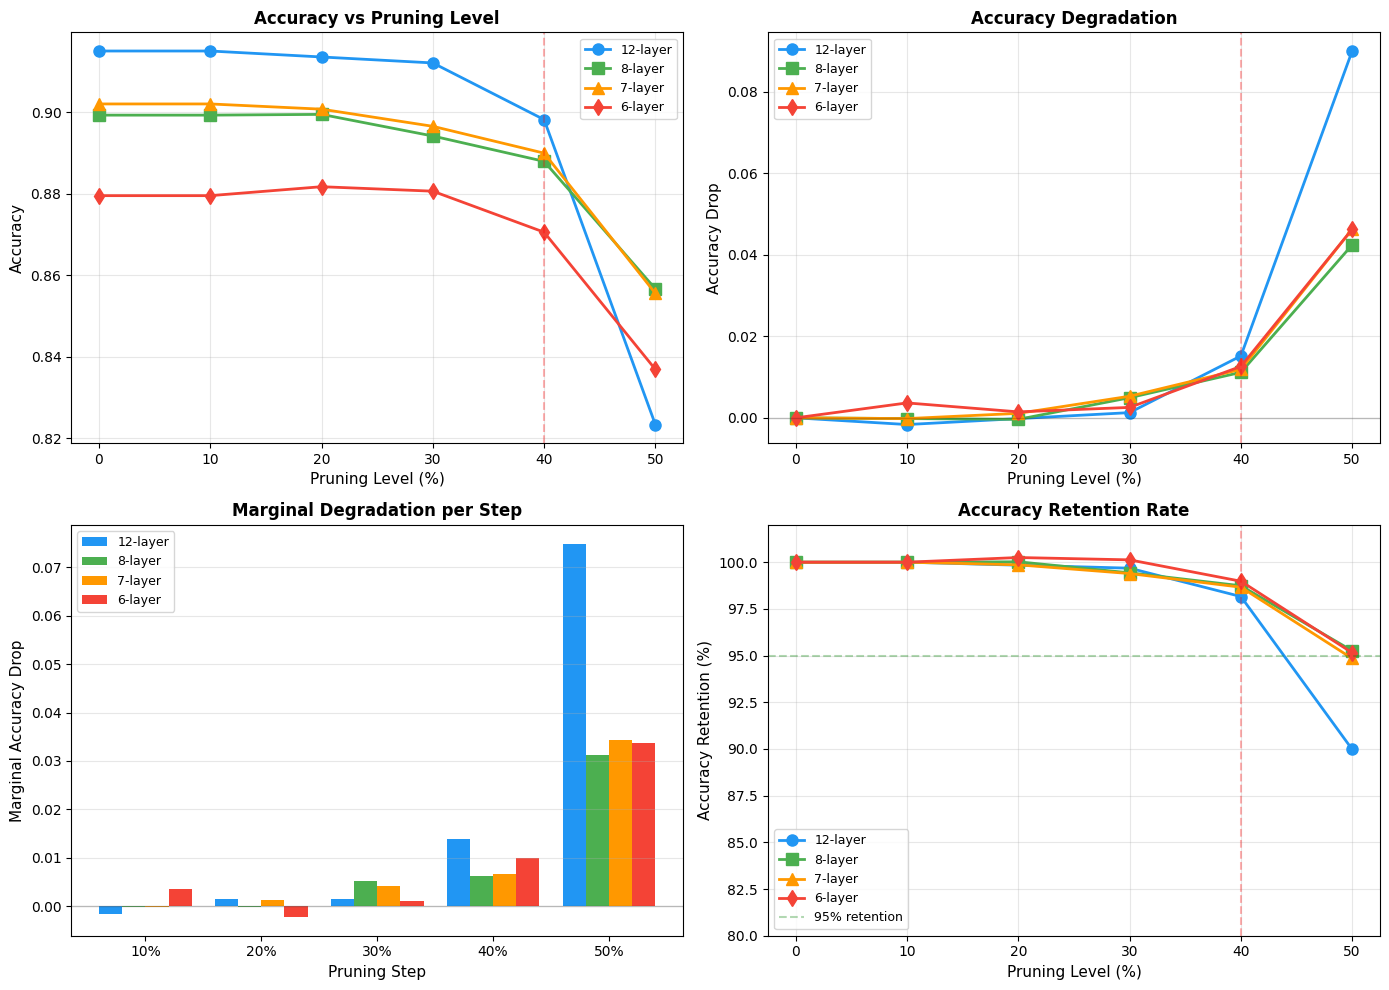

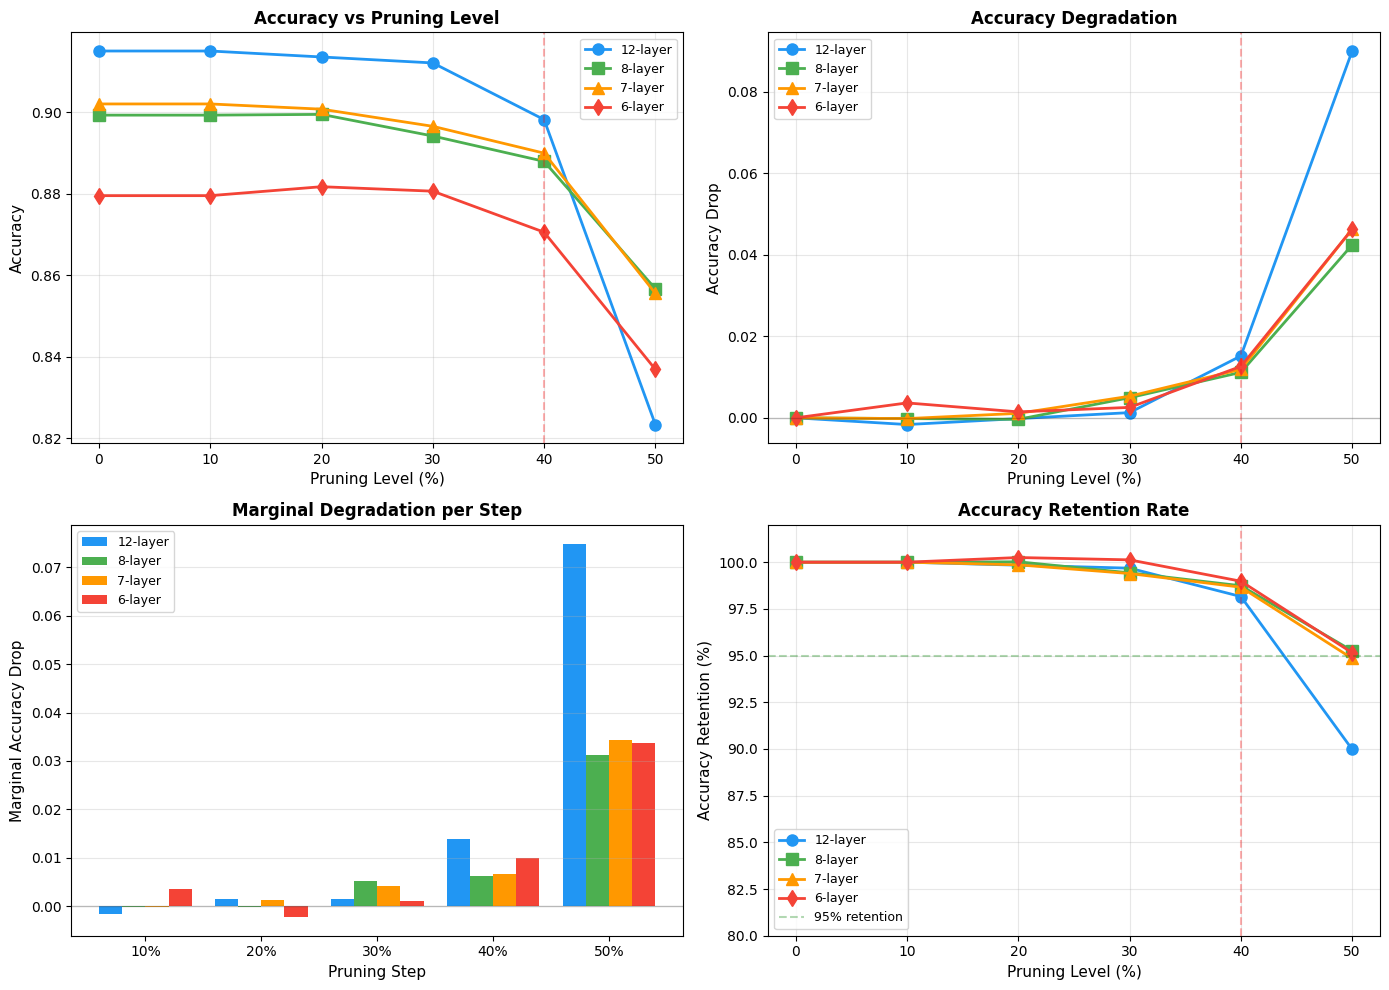

In [59]:
plot_pruning_comparison(results_dict=results)

# 6. Global Pruning — Attention vs FFN Separately

**Local pruning** (Section 5) removes the lowest X% of weights *within each layer*,
treating every layer equally regardless of how important its weights are.

**Global pruning** ranks weights *across all layers of the same type* and removes
the globally weakest ones — so some layers get pruned more than others based on
their actual weight magnitudes. This is generally smarter.

We split the model into **two global pools**:

| Pool | Layers included |
|---|---|
| **Attention** | `query`, `key`, `value`, `attention.output.dense` across all encoder layers |
| **FFN** | `intermediate.dense`, `output.dense` across all encoder layers |

This lets you control attention sparsity and FFN sparsity independently —
e.g. prune FFN aggressively (it's 2/3 of BERT's parameters) while being
gentler on attention.


In [56]:
from prune_helper import get_global_pruning_params, apply_global_pruning, pool_sparsity, remove_global_masks, remove_all_global_masks, describe_pools, print_per_layer_sparsity, compare_global_pruning_robustness

## Inspect Pool Sizes

In [57]:
describe_pools(model,  'Depth model (12-layer standard BERT)')
describe_pools(model_8, 'Width model (8-layer merged BERT)')
describe_pools(model_7, 'Width model (7-layer merged BERT)')
describe_pools(model_6, 'Width model (6-layer merged BERT)')


── Depth model (12-layer standard BERT) ──
  Attention pool :  48 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  24 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      72 Linear layers  |    84,934,656 params

── Width model (8-layer merged BERT) ──
  Attention pool :  32 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  16 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      48 Linear layers  |    84,934,656 params

── Width model (7-layer merged BERT) ──
  Attention pool :  28 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  14 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      42 Linear layers  |    84,934,656 params

── Width model (6-layer merged BERT) ──
  Attention pool :  24 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  12 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      36 Linear layers  |    84,934,656 params


## Global Pruning Sweep¶

In [58]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
  ★ accuracy: 0.9134

8-layer:
  ★ accuracy: 0.8991

7-layer:
  ★ accuracy: 0.9019

6-layer:
  ★ accuracy: 0.8832

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  Uniform 10%
══════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.9158  (Δ -0.0024)
    Attn sparsity: 10.00%
    FFN sparsity:  10.00%
    Total sparsity: 10.00%

  [8-layer]
    Accuracy: 0.8995  (Δ -0.0004)
    Attn sparsity: 10.00%
    FFN sparsity:  10.00%
    Total sparsity: 10.00%

  [7-layer]
    Accuracy: 0.9012  (Δ +0.0007)
    Attn sparsity: 10.00%
    FFN sparsity:  10.00%
    Total sparsity: 10.00%

  [6-layer]
    Accuracy: 0.8803  (Δ +0.0029)
    Attn sparsity: 10.00%
    FFN sparsity:  10.00%
    Total sparsity: 10.00%

═══════════════════════════════════════════════════════════

In [59]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False,
    pruning_configs=[
        (0, 0.2),  # FFN-only 20%
        (0, 0.3),  # FFN-only 30%
        (0, 0.4),  # FFN-only 40%
        (0, 0.5),  # FFN-only 50%
    ]
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
  ★ accuracy: 0.9134

8-layer:
  ★ accuracy: 0.8991

7-layer:
  ★ accuracy: 0.9019

6-layer:
  ★ accuracy: 0.8832

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  FFN-only 20%
══════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.8325  (Δ +0.0809)
    FFN sparsity:  50.00%

  [8-layer]
    Accuracy: 0.8453  (Δ +0.0538)
    FFN sparsity:  50.00%

  [7-layer]
    Accuracy: 0.8514  (Δ +0.0505)
    FFN sparsity:  50.00%

  [6-layer]
    Accuracy: 0.8320  (Δ +0.0513)
    FFN sparsity:  50.00%

══════════════════════════════════════════════════════════════
  FFN-only 30%
══════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.8325  (Δ +0.0809)
    FFN sparsity:  50.00%

  [8-layer]
    Accuracy: 0.8453  (Δ +0.0538)
    FFN 

In [60]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False,
    pruning_configs=[
        (0.2, 0),  # Attn-only 20%
        (0.3, 0),  # Attn-only 30%
        (0.4, 0),  # Attn-only 40%
        (0.5, 0),  # Attn-only 50%
    ]
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
  ★ accuracy: 0.9134

8-layer:
  ★ accuracy: 0.8991

7-layer:
  ★ accuracy: 0.9019

6-layer:
  ★ accuracy: 0.8832

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  Attn-only 20%
══════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.8325  (Δ +0.0809)
    Attn sparsity: 50.00%

  [8-layer]
    Accuracy: 0.8453  (Δ +0.0538)
    Attn sparsity: 50.00%

  [7-layer]
    Accuracy: 0.8514  (Δ +0.0505)
    Attn sparsity: 50.00%

  [6-layer]
    Accuracy: 0.8320  (Δ +0.0513)
    Attn sparsity: 50.00%

══════════════════════════════════════════════════════════════
  Attn-only 30%
══════════════════════════════════════════════════════════════

  [12-layer]
    Accuracy: 0.8325  (Δ +0.0809)
    Attn sparsity: 50.00%

  [8-layer]
    Accuracy: 0.8453  (Δ +0.0538)
    At